## Training back
code was adapted from 
https://github.com/kinivi/hand-gesture-recognition-mediapipe/blob/main/keypoint_classification_EN.ipynb
and 
https://www.tensorflow.org/api_docs/python/tf/keras/Model
and 
https://www.youtube.com/watch?v=a99p_fAr6e4&t=899s 

In [1]:
pip install pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
# import libraries 
import csv
import json
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import matplotlib.pyplot as plt

import os


In [5]:
# Extract negative samples as well 
# tried without asw but it just counted everything as "back" gesture (final accuracy of 100%) (false positives)

os.makedirs("data", exist_ok=True)

ANNOTATIONS_DIR = 'annotations'
OUTPUT_CSV = 'data/back_gestures.csv' # store the final flattened numerical data output

def extract_all_samples():
    all_gesture_samples = []
    
    gesture_map = {
        'three_gun': 1,    # positives
        'like': 0,         # false positives, negatives 
        'dislike': 0,
        'palm': 0,
        'peace': 0
    }
    
    for gesture_name, label in gesture_map.items():
        print(f"Processing {gesture_name} (label={label}):")
        
        for split in ['test', 'train', 'val']:
            json_path = f'{ANNOTATIONS_DIR}/{split}/{gesture_name}.json' # loop thru the train, test, val paths

            # open json annotation 
            with open(json_path, 'r') as f:
                data = json.load(f)
            
            count = 0
            
            for image_id, annotation in data.items():
                if 'hand_landmarks' not in annotation:
                    continue            
                if not annotation['hand_landmarks']: 
                    continue
                
                for hand in annotation['hand_landmarks']:
                    if hand is None or len(hand) != 21:
                        continue
                    
                    # flatten to 2D (x, y) to store all coordinates
                    landmarks_flat = []
                    for point in hand:
                        if len(point) >= 2:
                            landmarks_flat.extend([point[0], point[1]])
                    
                    if len(landmarks_flat) == 42:
                        all_gesture_samples.append([label] + landmarks_flat)
                        count += 1
                        
                # limit negatives to balance the dataset
                if label == 0 and count >= 5000:
                    break
            print(f"{split}: {count} samples")
            
    print(f"\nTotal samples: {len(all_gesture_samples)}")    
    
    # count labels 
    labels = [s[0] for s in all_gesture_samples]
    print(f"Label 0 (not back): {labels.count(0)}")
    print(f"Label 1 (back): {labels.count(1)}")

    with open(OUTPUT_CSV, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerows(all_gesture_samples)

    print(f"Saved to {OUTPUT_CSV}")
    
#extract_all_samples()
if __name__ == "__main__":
    extract_all_samples()

Processing three_gun (label=1):
test: 6326 samples
train: 36657 samples
val: 3845 samples
Processing like (label=0):
test: 5001 samples
train: 5000 samples
val: 3657 samples
Processing dislike (label=0):
test: 5000 samples
train: 5000 samples
val: 3641 samples
Processing palm (label=0):
test: 5000 samples
train: 5001 samples
val: 3609 samples
Processing peace (label=0):
test: 5000 samples
train: 5000 samples
val: 3577 samples

Total samples: 101314
Label 0 (not back): 54486
Label 1 (back): 46828
Saved to data/back_gestures.csv


Code adapted from: https://milvus.io/ai-quick-reference/what-are-negative-sampling-and-its-role-in-embedding-training

In [6]:
RANDOM_SEED = 42

# paths
dataset = 'data/back_gestures.csv' 
model_save_path = 'models/back_gesture_model_v2.keras' # hdf5 on repo 
tflite_save_path = 'models/back_gesture_model_v2.tflite'

NUM_CLASSES = 2 # classes 0 and 1

# read dataset
data = np.loadtxt(dataset, delimiter=',', dtype='float32')

X_dataset = data[:, 1:] # features (42 values (21*2))
y_dataset = data[:, 0].astype('int32')  # labels

In [7]:
# check dataset
print(f"Dataset shape: {X_dataset.shape}")

# check for class imbalance
print(f"\nLabel distribution:")

unique, counts = np.unique(y_dataset, return_counts=True)

for label, count in zip(unique, counts):
    label_name = "Not Back" if label == 0 else "Back"
    print(f"{label} ({label_name}): {count} samples ({count/len(y_dataset)*100:.1f}%)")

imbalance_ratio = max(counts)/min(counts)
print(f"\nImbalance ratio: {imbalance_ratio:.2f}")

# data validation
print("\nData validation:")
print(f"Feature range: [{X_dataset.min():.3f}, {X_dataset.max():.3f}]") # expected [0,1] range
print(f"Feature mean: {X_dataset.mean():.3f}")
print(f"NaN: {np.isnan(X_dataset).any()}") # 
print(f"Inf: {np.isinf(X_dataset).any()}") # label noise filters for

Dataset shape: (101314, 42)

Label distribution:
0 (Not Back): 54486 samples (53.8%)
1 (Back): 46828 samples (46.2%)

Imbalance ratio: 1.16

Data validation:
Feature range: [-0.105, 1.115]
Feature mean: 0.543
NaN: False
Inf: False


In [8]:
# split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_dataset, y_dataset, 
    test_size = 0.25,
    train_size = 0.75, 
    random_state = RANDOM_SEED,
    stratify = y_dataset        # ensure balanced splits
)

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

print("\nTrain label distribution:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    print(f"{label}: {count} ({count/len(y_train)*100:.1f}%)")

Train samples: 75985
Test samples: 25329

Train label distribution:
0: 40864 (53.8%)
1: 35121 (46.2%)


In [9]:
# compute class weights
class_weights_array = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))

print(f"Class weights: {class_weights}")

Class weights: {0: 0.9297303249804229, 1: 1.0817602004498732}


In [10]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2,)),
    
    # normalisation
    tf.keras.layers.BatchNormalization(),
    
    # Main network
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 42)             │           168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,106 (8.23 KB)

 Trainable params: 2,022 (7.90 KB)

 Non-trainable params: 84 (336.00 B)

In [11]:
# compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)

# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [13]:
# train
history = model.fit(
    X_train,
    y_train,
    epochs = 200,
    batch_size = 32,
    validation_data = (X_test, y_test),
    class_weight = class_weights,  # handle imbalance
    callbacks=[cp_callback, es_callback],
    verbose=1
)

# eval
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)
print(f"\nTest Accuracy: {val_acc*100:.2f}%")
print(f"Test Loss: {val_loss:.4f}")

Epoch 1/200


## convert to tensorflow 

In [ ]:
# convert to tensorflow
model.save(model_save_path, include_optimizer=False)

# transform model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /var/folders/_w/6srl00kn0wg_p3hd3cxbt99c0000gn/T/tmp5ez9q6gv/assets


INFO:tensorflow:Assets written to: /var/folders/_w/6srl00kn0wg_p3hd3cxbt99c0000gn/T/tmp5ez9q6gv/assets


Saved artifact at '/var/folders/_w/6srl00kn0wg_p3hd3cxbt99c0000gn/T/tmp5ez9q6gv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  6372292064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6372284144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6372294176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6372292768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6372289248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6372289776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6372293472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6372288016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6372286432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6372285552: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1777110624.451440 12458052 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1777110624.451469 12458052 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1777110624.453840 12458052 reader.cc:83] Reading SavedModel from: /var/folders/_w/6srl00kn0wg_p3hd3cxbt99c0000gn/T/tmp5ez9q6gv
I0000 00:00:1777110624.454284 12458052 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1777110624.454289 12458052 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/_w/6srl00kn0wg_p3hd3cxbt99c0000gn/T/tmp5ez9q6gv
I0000 00:00:1777110624.461590 12458052 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1777110624.462675 12458052 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1777110624.492921 12458052 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/_w/6srl00kn0wg_p3hd3cxbt99c0000gn/T/tmp5ez9q6gv
I0000 00:00:1777110624.502910 12

6672

In [ ]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9346 - loss: 0.1221


In [ ]:
# Load the saved model
model = tf.keras.models.load_model(model_save_path)

In [ ]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
[0.9967892  0.00321085]
0


792/792 ━━━━━━━━━━━━━━━━━━━━ 0s 244us/step


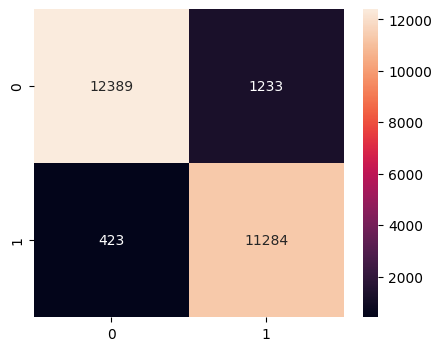

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.91      0.94     13622
           1       0.90      0.96      0.93     11707

    accuracy                           0.93     25329
   macro avg       0.93      0.94      0.93     25329
weighted avg       0.94      0.93      0.93     25329



In [ ]:
# confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# inference test

In [ ]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

# Get I/O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [ ]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

In [ ]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))